# Molecular Melting Point Prediction using RDKit and Machine Learning

### About this Project

This project is my attempt to explore how **Machine Learning** can be used to predict the **melting point of molecules** from their chemical structure.

As someone interested in both **Chemistry** and **Machine Learning**, I wanted to work on a project that combines these two fields. Instead of using image or text datasets, this project focuses on molecular data represented as **SMILES** (Simplified Molecular Input Line Entry System).

Using the **RDKit** library, I will convert these molecular structures into numerical features (called molecular descriptors and fingerprints) that can be understood by Machine Learning models. I will then train different regression models and compare their performance in predicting melting points.

---

## What I Hope to Learn

Through this project, I aim to:

- Understand how molecular datasets are structured.
- Learn how RDKit represents molecules.
- Generate molecular descriptors and fingerprints.
- Build and evaluate Machine Learning regression models.
- Explore the connection between chemistry and data science.

---

## Project Workflow

1. Load and understand the dataset.
2. Clean and inspect the data.
3. Process SMILES using RDKit.
4. Generate molecular descriptors.
5. Train Machine Learning models.
6. Evaluate model performance.
7. Compare different approaches and summarize the results.

---

## Dataset

This project uses the **Jean-Claude Bradley Open Melting Point Dataset**, which contains experimentally measured melting points and molecular SMILES.


In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the Dataset
The objective is to:

- Load the Excel dataset.
- Check the dimensions of the dataset.
- View the first few rows.
- Understand the available columns before beginning data preprocessing.

In [3]:
dataset = pd.read_excel("BradleyMeltingPointDataset.xlsx")
dataset.head()

,key,name,smiles,mpC,csid,link,source,donotuse,donotusebecause
0,1,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,64018,http://www.alfa.com/en/GP100W.pgm?DSSTK=B24192,Alfa Aesar,NaN,NaN
1,2,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,403764,http://www.alfa.com/en/GP100W.pgm?DSSTK=A13073,Alfa Aesar,NaN,NaN
2,3,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,80080,http://www.alfa.com/en/GP100W.pgm?DSSTK=L15884,Alfa Aesar,NaN,NaN
3,4,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,63701,http://www.alfa.com/en/GP100W.pgm?DSSTK=B20252,Alfa Aesar,NaN,NaN
4,5,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,69388,http://www.alfa.com/en/GP100W.pgm?DSSTK=L08261,Alfa Aesar,NaN,NaN


In [4]:
dataset.shape

(28645, 9)

# 2. Data Cleaning (PRE OF Preprocessing)

Before training any Machine Learning model, it is important to clean the dataset. Real-world datasets often contain missing values, duplicate entries, invalid records, or information that is not useful for prediction.

In this phase, I will inspect the dataset and remove unnecessary or unreliable data while keeping the important information required for the project.

For this project, the two most important columns are:

- **name** – The common name of the molecule. This helps identify molecules while exploring the dataset.
- **smiles** – The molecular structure represented in SMILES format. This will be processed using RDKit to generate molecular features.
- **mpC** – The experimental melting point (in °C), which is the target variable for prediction.

The remaining columns contain identifiers, links, metadata, and quality information that are not required for model training. After cleaning, the dataset will be ready for molecular preprocessing and feature generation.

In [5]:
data = dataset[['name','smiles','mpC']]
data.head()

,name,smiles,mpC
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0


In [6]:
# lets see if we have a new null values or not
data.isnull().sum()

name      0
smiles    0
mpC       0
dtype: int64

looks good if we don't have null values in data we have

# 3. Processing SMILES with RDKit

Machine Learning models cannot directly understand chemical structures written as **SMILES (Simplified Molecular Input Line Entry System)**. Therefore, the first step is to convert these text representations into molecular objects using the **RDKit** library.

In this phase, I will:

- Convert each SMILES string into an RDKit molecule (`Mol`) object.
- Check for invalid or corrupted SMILES strings.
- Remove molecules that cannot be processed correctly.
- Prepare the dataset for molecular descriptor and fingerprint generation in the next phase.

By the end of this phase, every row in the dataset will contain a valid molecular structure that can be analyzed computationally.

In [7]:
import rdkit.Chem as Chem

In [8]:
data['mol'] = data['smiles'].apply(Chem.MolFromSmiles)

[19:07:27] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 22 23 24
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 7 8 10 11 12 13 15 16 17 19
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 6 7 8 9 11 12 13 15 16 17 18
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 21 22 23
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 11 12 13 15 16 17 18 19 20 21 22
[19:07:27] Explicit valence for atom # 20 C, 5, is greater than permitted
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 16 17 18 19 20 21 22 23 24
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 16 17 23
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[19:07:27] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 7 

as we observe in data we have certain abnormal points

In [9]:
# Count invalid molecules

invalid = data["mol"].isna().sum()

print(f"Invalid molecules: {invalid}")
print(f"Valid molecules  : {len(data) - invalid}")

Invalid molecules: 301
Valid molecules  : 28344


301 from 28645 its around 1.05% of data better messing up with this we should remove that fraction having data size of 28344 entries in it... still works good

In [10]:
data = data[data['mol'].notna()].reset_index(drop = True)

In [11]:
data.head()

,name,smiles,mpC,mol
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,<rdkit.Chem.rdchem.Mol object at 0x7ba9e17c4350>
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,<rdkit.Chem.rdchem.Mol object at 0x7ba9e17c43c0>
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,<rdkit.Chem.rdchem.Mol object at 0x7ba9e17c4430>
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,<rdkit.Chem.rdchem.Mol object at 0x7ba9e17c44a0>
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,<rdkit.Chem.rdchem.Mol object at 0x7ba9e17c4510>


In [12]:
data.shape

(28344, 4)

# 4. Molecular Descriptor Generation

Machine Learning models cannot learn directly from molecular structures. They require numerical features as input.

In this phase, I will use **RDKit** to calculate molecular descriptors for each molecule. These descriptors describe different physical, chemical, and structural properties of a molecule, such as its molecular weight, number of atoms, hydrogen bond donors and acceptors, topological properties, and many others.

These numerical values will become the **features (X)** that the Machine Learning models use to predict the **melting point (mpC)**.

The objective of this phase is to convert every valid molecule into a set of meaningful numerical descriptors while preserving the melting point as the target variable.

In [13]:
from rdkit.Chem import Descriptors

descriptor_names = [name for name, _ in Descriptors.descList]

def calculate_all_descriptors(mol):
    return [func(mol) for _, func in Descriptors.descList]

descriptor_data = pd.DataFrame(
    data["mol"].apply(calculate_all_descriptors).tolist(),
    columns=descriptor_names
)

final_data = pd.concat(
    [data[["name", "smiles", "mpC", "mol"]], descriptor_data],
    axis=1
)

In [14]:
descriptor_data = descriptor_data.dropna(axis=1)

In [15]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)

selector.fit(descriptor_data)

descriptor_data = descriptor_data.loc[:, selector.get_support()]

In [16]:
correlation = descriptor_data.corrwith(final_data["mpC"])

In [17]:
top_descriptors = correlation.head(30).index.tolist()

print(top_descriptors)

['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha']


In [18]:
data = pd.concat(
    [
        final_data[["name", "smiles", "mpC"]],
        descriptor_data[top_descriptors]
    ],
    axis=1
)

In [19]:
data.head()

,name,smiles,mpC,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,10.949337,10.949337,0.259075,-0.655211,0.619888,10.105263,259.221,...,9.075387,5.393132,5.393132,3.825087,3.825087,2.574114,2.574114,1.683069,1.683069,-2.83
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,5.909724,5.909724,0.906852,0.906852,0.664933,17.384615,176.263,...,6.377010,4.972088,4.972088,3.606524,3.606524,2.633505,2.633505,1.910324,1.910324,-1.18
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,4.189444,4.189444,0.846296,0.846296,0.628312,17.833333,164.212,...,5.966326,4.193447,4.193447,2.785840,2.785840,1.951981,1.951981,1.319357,1.319357,-1.16
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,9.600688,9.600688,0.379074,0.379074,0.667456,17.384615,178.235,...,6.377010,4.614126,4.614126,3.225762,3.225762,2.339415,2.339415,1.637308,1.637308,-1.22
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,5.418520,5.418520,0.825231,0.825231,0.559754,19.444444,125.215,...,4.431852,3.812278,3.812278,2.646829,2.646829,1.850480,1.850480,1.317105,1.317105,-0.30


In [20]:
# Correlation matrix of the selected descriptors

corr_matrix = descriptor_data[top_descriptors].corr().abs()


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

)

threshold = 0.95

to_drop = [
    column
    for column in upper.columns
    if any(upper[column] > threshold)
]

print("Descriptors to remove:")
print(to_drop)

selected_descriptors = [
    desc for desc in top_descriptors
    if desc not in to_drop
]

print(f"Descriptors before : {len(top_descriptors)}")
print(f"Descriptors after  : {len(selected_descriptors)}")

data = pd.concat(
    [
        final_data[["name", "smiles", "mpC"]],
        descriptor_data[selected_descriptors]
    ],
    axis=1
)


Descriptors to remove:
['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi3n', 'Chi4n', 'Chi4v']
Descriptors before : 30
Descriptors after  : 17


In [21]:
data.head()

,name,smiles,mpC,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumValenceElectrons,NumRadicalElectrons,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,AvgIpc,BalabanJ,BertzCT,Chi2v,Chi3v,HallKierAlpha
0,"2-(2,4-dinitrobenzyl)pyridine",c1ccnc(c1)Cc2ccc(cc2[N+](=O)[O-])[N+](=O)[O-],92.0,10.949337,0.259075,-0.655211,0.619888,10.105263,259.221,96,0,1.052632,1.842105,2.421053,2.394721,2.399145,628.126552,3.825087,2.574114,-2.83
1,2-(1-piperidinyl)aniline,c1ccc(c(c1)N)N2CCCCC2,46.0,5.909724,0.906852,0.906852,0.664933,17.384615,176.263,70,0,1.000000,1.692308,2.384615,2.198429,2.183880,277.173697,3.606524,2.633505,-1.18
2,2-(1-piperazinyl)pyrimidine,c1cnc(nc1)N2CCNCC2,33.0,4.189444,0.846296,0.846296,0.628312,17.833333,164.212,64,0,1.166667,1.833333,2.500000,2.206795,2.082510,230.072993,2.785840,1.951981,-1.16
3,2-(1-piperazinyl)phenol,c1ccc(c(c1)N2CCNCC2)O,125.0,9.600688,0.379074,0.379074,0.667456,17.384615,178.235,70,0,1.153846,1.846154,2.538462,2.198429,2.183880,282.008164,3.225762,2.339415,-1.22
4,2-(1-cyclohexenyl)ethylamine,C1CCC(=CC1)CCN,-55.0,5.418520,0.825231,0.825231,0.559754,19.444444,125.215,52,0,1.444444,2.333333,2.888889,1.910086,2.281634,105.135263,2.646829,1.850480,-0.30


From 217 total no of descriptors, choose top 30 of them on having a look at them any of them were actually coorrelated to each other we need to remove them as well so all those who where coorrelated we find top 17 desciptors

In [22]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
mpC,28344.0,94.396756,97.018968,-2.050000e+02,35.000000,97.000000,163.000000,804.000000
MaxAbsEStateIndex,28344.0,9.283005,3.272410,0.000000e+00,6.471745,10.410073,11.702279,17.808922
MinAbsEStateIndex,28344.0,0.405819,0.513606,0.000000e+00,0.087523,0.245938,0.565618,9.847222
MinEStateIndex,28344.0,-0.518435,1.439937,-1.124769e+01,-0.902990,-0.333333,0.370060,6.000000
qed,28344.0,0.567242,0.156861,1.979820e-02,0.463261,0.569267,0.677727,0.945893
SPS,28344.0,14.264463,9.482476,0.000000e+00,9.600000,10.666667,14.133333,108.000000
MolWt,28344.0,224.013884,106.986420,1.604300e+01,151.165000,200.295500,278.308000,1701.206000
NumValenceElectrons,28344.0,80.065340,39.487402,1.000000e+00,54.000000,70.000000,100.000000,632.000000
NumRadicalElectrons,28344.0,0.000529,0.027215,0.000000e+00,0.000000,0.000000,0.000000,3.000000
FpDensityMorgan1,28344.0,1.137714,0.346106,6.756757e-02,0.909091,1.157895,1.363636,4.000000


In [24]:
# Lowest melting points
print(data.nsmallest(10, "mpC")[["name", "mpC"]])

# Highest melting points
print(data.nlargest(10, "mpC")[["name", "mpC"]])

                                     name     mpC
15631                    Carbon monooxide -205.00
22265                     carbon monoxide -205.00
17987  1-chloro-1,2,2,2-tetrafluoroethane -199.00
19080       ethanamine, n-ethyl-n-methyl- -196.00
16152            Trioxid-2-en-2-ium-1-ide -193.00
17569                               ozone -193.00
16052                             Propane -188.00
28172                             propane -187.65
21158                             propane -187.60
27937                             methane -187.45
                                                  name    mpC
28227                                  sodium chloride  804.0
27006      4-[(4-Ethoxyphenyl)amino]quinolin-2(1H)-one  562.0
27434                  aceclofenac valine methyl aster  517.0
27432                 aceclofenac leucine methyl aster  505.0
20153                                     violanthrone  492.5
27968                                            mirex  485.0
27969           

# 5. Machine Learning Model Development

In this phase, the prepared molecular descriptors will be used to train supervised Machine Learning models for predicting the melting point of molecules.

The selected molecular descriptors will serve as the input features (**X**), while the experimental melting point (**mpC**) will be used as the target variable (**y**).

Several regression algorithms will be trained and evaluated to compare their prediction performance. Each model will be assessed using standard regression metrics, allowing a fair comparison of their ability to learn the relationship between molecular descriptors and melting point.

The objective of this phase is to identify the regression model that provides the most accurate and reliable predictions for this dataset.

### Tasks

- Prepare the feature matrix (**X**) and target variable[Melting points] (**y**)
- Split the dataset into training and testing sets
- Train multiple regression models
- Evaluate model performance
- Compare the results of different algorithms
- Select the best-performing model

In [ ]:
X = data[selected_descriptors]
Y = data['mpC']
print(X.shape,Y.shape)

(28344, 17) (28344,)


## 1. Calling Linear Regression Model

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 0.65,-31.7 , -1.69,..., -2.02, 5.26,-42.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['MaxAbsEStateIndex','MinAbsEStateIndex','MinEStateIndex',...,'Chi2v', 'Chi3v','HallKierAlpha']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-140.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,17


In [32]:
# Predict melting points
y_pred_lr = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error as mae , mean_squared_error  as mse, r2_score as r2

I have define these two functions, so that i don't want to repeat same line of code and for every model

In [46]:
def tester(y_true, y_pred):
    mae_score = mae(y_true, y_pred)
    mse_score = mse(y_true, y_pred)
    rmse_score = np.sqrt(mse_score)
    r2_score_value = r2(y_true, y_pred)

    print(f"MAE  : {mae_score:.2f}")
    print(f"MSE  : {mse_score:.2f}")
    print(f"RMSE : {rmse_score:.2f}")
    print(f"R²   : {r2_score_value:.4f}")

    return {
        "MAE": mae_score,
        "MSE": mse_score,
        "RMSE": rmse_score,
        "R2": r2_score_value
    }



In [47]:
def plotting(y_true, y_pred, model_name="Model"):
    plt.figure(figsize=(7, 6))

    plt.scatter(y_true, y_pred, alpha=0.5)

    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        'r--',
        linewidth=2
    )

    plt.xlabel("Actual Melting Point (°C)")
    plt.ylabel("Predicted Melting Point (°C)")
    plt.title(f"{model_name}: Actual vs Predicted")

    plt.grid(True)
    plt.show()

In [50]:
lr_result = tester(Y_test,y_pred_lr)

MAE  : 54.15
MSE  : 4802.09
RMSE : 69.30
R²   : 0.4970


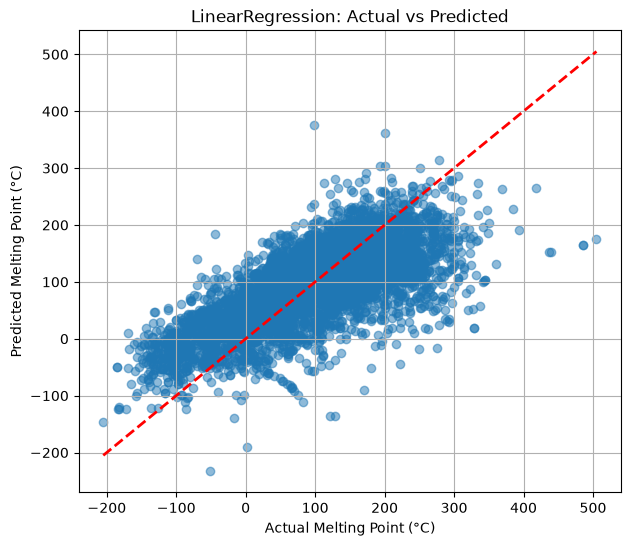

In [49]:
plotting(Y_test,y_pred_lr,"LinearRegression")